In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

In [54]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [72]:
# Abramov Glacier coordinates:
abra_lat = 39.66
abra_lon = 71.50

In [73]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [74]:
domain_2 = 'GRp'
domain_3 = 'GRp_bug'

In [75]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
# sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [76]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [77]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve le glacier Abramov

# distance sur grille
dist = np.sqrt((ds_lat - abra_lat)**2 + (ds_lon - abra_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Caratéristique de la maille MAR ou se trouve le glacier Abramov")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())
print("Altitude :", ds_SH[iY, iX].item())

Caratéristique de la maille MAR ou se trouve le glacier Abramov
Indice Y : 44
Indice X : 37
Latitude : 39.67844009399414
Longitude : 71.48213958740234
Altitude : 4171.5380859375


/tmp/ipykernel_1914088/1803992992.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


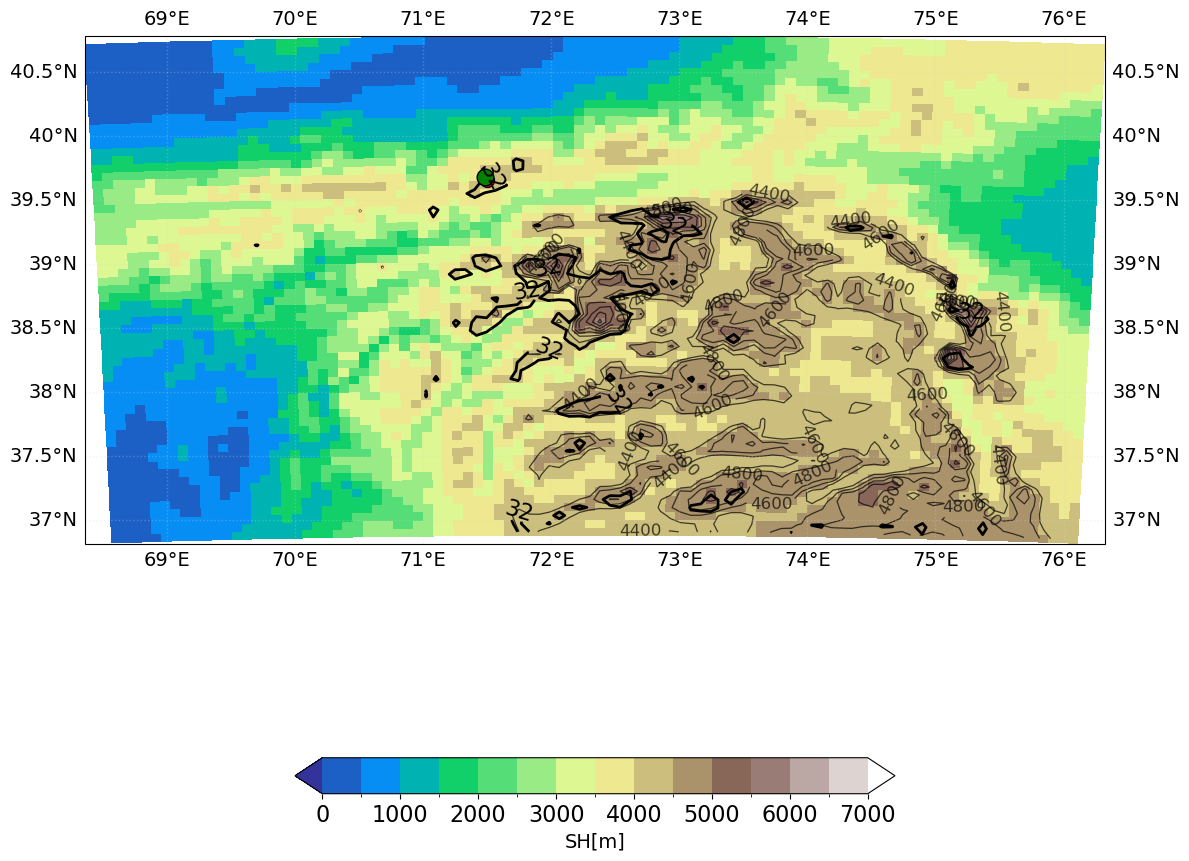

In [81]:
ice_level=32# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
#             levels=[10,ice_level,100],
#             hatches=['','X','X'],
#             colors="none",
#             transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[4400,4600,4800,5000,5200,5400,5600,5800,6000,6200,6400,6600,6800,7000],
                             colors="k", linewidths=0.9, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
# ax.set_extent([71, 72, 39.4, 40], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="lightgray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Abramov Glacier: red dot
ax.plot(abra_lon, abra_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

# Identifier le point de grille ou se trouve la carotte Jasgulem
ax.plot(ds_lon[iY, iX], ds_lat[iY, iX],
        marker='o', markersize=12,
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())

plt.show()

/tmp/ipykernel_1914088/3488911541.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


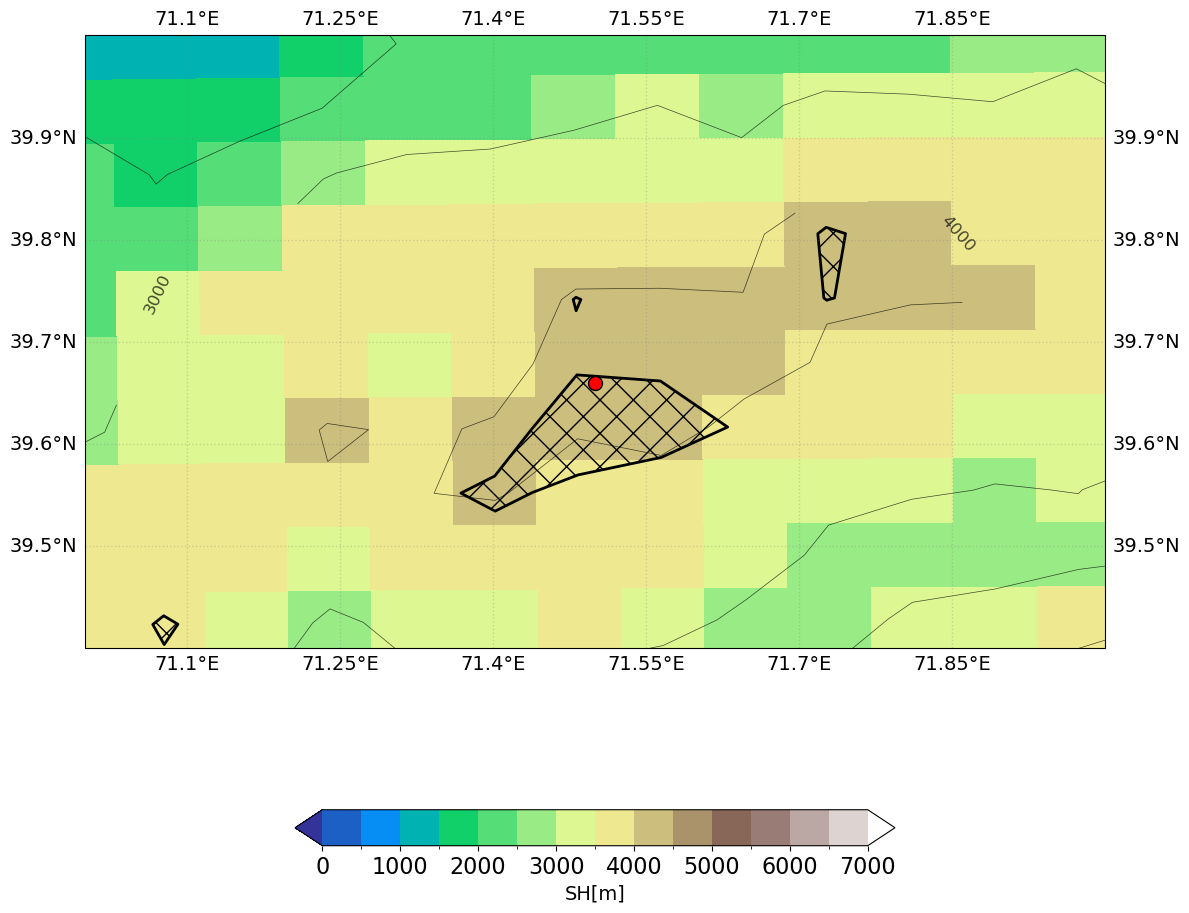

In [83]:
ice_level=40# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
ax.set_extent([71, 72, 39.4, 40], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Abramov Glacier : red dot
ax.plot(abra_lon, abra_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

plt.show()

### MAR datasets

# A ajouter ici : ds_ME, ds_RZ et ds_SW


In [84]:
variable='TTZ' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1950-2024.nc'
ds_TTZ= xr.open_dataset(sourceData_1+fileNameF).isel(ZTQLEV=0).TTZ.load()

ds_TTZ = ds_TTZ.assign_coords(X=np.round(ds_TTZ.X.values))
ds_TTZ = ds_TTZ.assign_coords(Y=np.round(ds_TTZ.Y.values))
ds_TTZ = ds_TTZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_TTZ = ds_TTZ[:,k:-k,k:-k]

In [85]:
variable='RF'

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1950-2024.nc'
ds_RF= xr.open_dataset(sourceData_1+fileNameF).RF.load()

ds_RF = ds_RF.assign_coords(X=np.round(ds_RF.X.values))
ds_RF = ds_RF.assign_coords(Y=np.round(ds_RF.Y.values))
ds_RF = ds_RF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RF = ds_RF[:,k:-k,k:-k]

In [86]:
variable='SF'

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1950-2024.nc'
ds_SF= xr.open_dataset(sourceData_1+fileNameF).SF.load()

ds_SF = ds_SF.assign_coords(X=np.round(ds_SF.X.values))
ds_SF = ds_SF.assign_coords(Y=np.round(ds_SF.Y.values))
ds_SF = ds_SF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SF = ds_SF[:,k:-k,k:-k]

In [87]:
variable='ME' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_ME= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRp_bug/spin2/work/monthly/'+fileNameF).ME.isel(SECTOR1_1=0).load()

ds_ME = ds_ME.assign_coords(X=np.round(ds_ME.X.values))
ds_ME = ds_ME.assign_coords(Y=np.round(ds_ME.Y.values))
ds_ME = ds_ME.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_ME = ds_ME[:,k:-k,k:-k]
ds_ME = - ds_ME



# Variable ME pas encore extraite pour nouvelles simues

# variable='ME' 

# fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
# ds_ME= xr.open_dataset(sourceData_1+fileNameF).ME.isel(SECTOR1_1=0).load()

# ds_ME = ds_ME.assign_coords(X=np.round(ds_ME.X.values))
# ds_ME = ds_ME.assign_coords(Y=np.round(ds_ME.Y.values))
# ds_ME = ds_ME.rename({'TIME': 'time'})

# # Enlever k pixels sur les contours
# ds_ME = ds_ME[:,k:-k,k:-k]
#ds_ME = - ds_ME

In [88]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1950-2024.nc'
ds_SMB= xr.open_dataset(sourceData_1+fileNameF).SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]

## Sorties de MAR au point de Grille Abramov Glacier

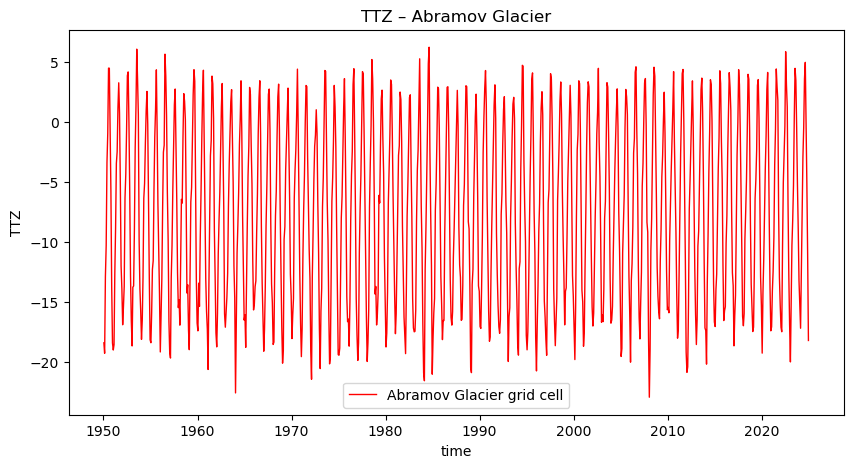

In [90]:
# TTZ at Jasgulem ice core site

plt.figure(figsize=(10,5))

ds_TTZ_abra =  ds_TTZ.isel(Y=iY, X=iX)
ds_TTZ_abra.plot(label="Abramov Glacier grid cell", linewidth=1, color="red")

plt.legend(ncol=3)
plt.title("TTZ – Abramov Glacier")
plt.ylabel("TTZ")
plt.show()

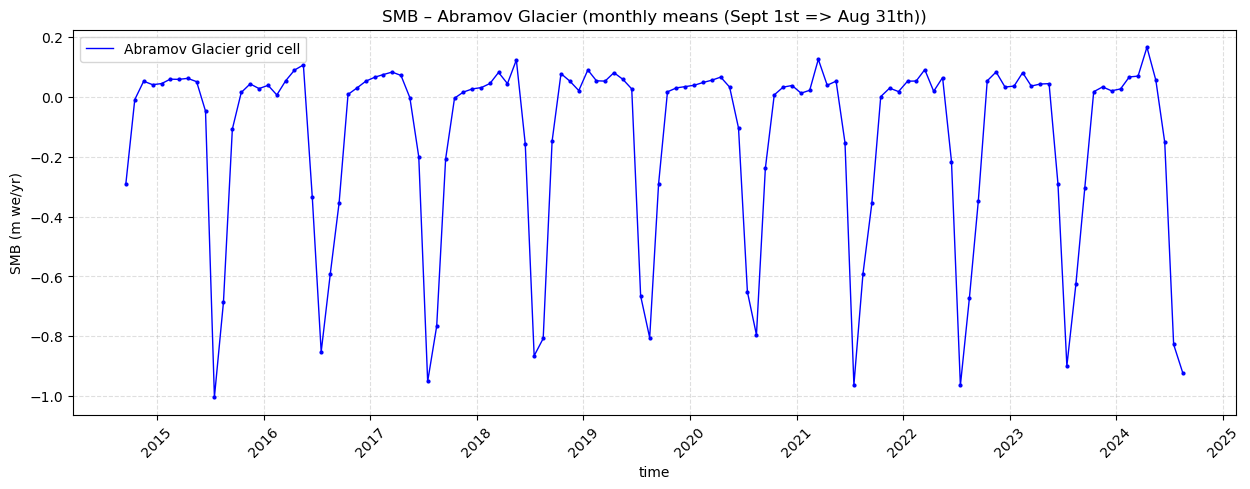

In [98]:
#SMB mensuel 

plt.figure(figsize=(15,5))

# Point précis Jasgulem
ds_SMB_abra = ds_SMB.isel(Y=iY, X=iX).sel(time=slice("2014-09-01", "2024-08-31"))/1000
# ds_SMB_abra_annual = ds_SMB_abra.resample(time="A-SEP").sum().sel(time=slice("1980-09-01", "2024-08-31"))/1000

ds_SMB_abra.plot(label="Abramov Glacier grid cell", linewidth=1, color="blue")

plt.plot(ds_SMB_abra.time,
         ds_SMB_abra,
         'o', color='blue', markersize=2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Abramov Glacier (monthly means (Sept 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

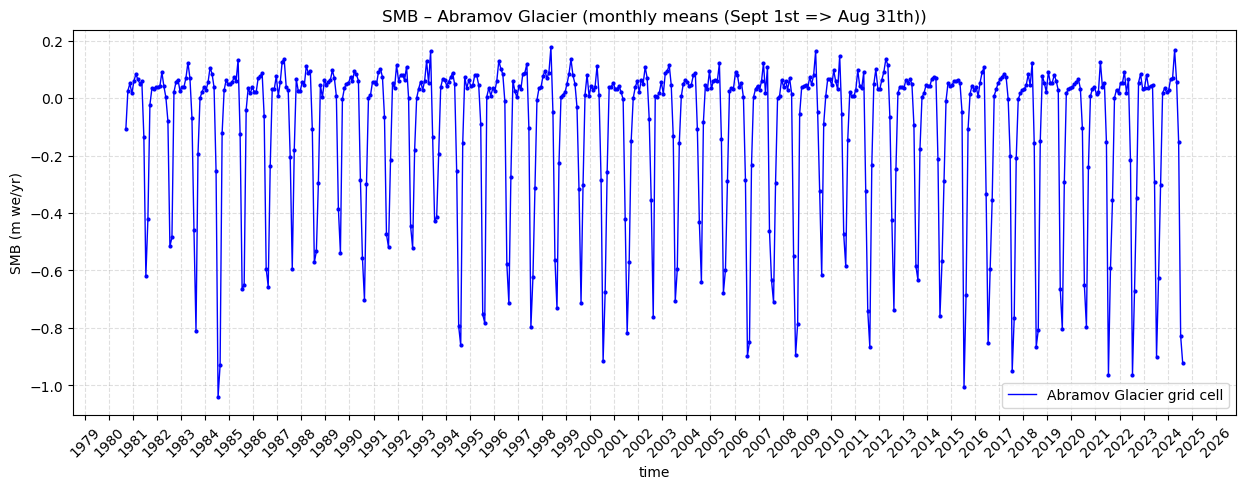

In [99]:
#SMB mensuel 

plt.figure(figsize=(15,5))

# Point précis Jasgulem
ds_SMB_abra = ds_SMB.isel(Y=iY, X=iX).sel(time=slice("1980-09-01", "2024-08-31"))/1000
# ds_SMB_abra_annual = ds_SMB_abra.resample(time="A-SEP").sum().sel(time=slice("1980-09-01", "2024-08-31"))/1000

ds_SMB_abra.plot(label="Abramov Glacier grid cell", linewidth=1, color="blue")

plt.plot(ds_SMB_abra.time,
         ds_SMB_abra,
         'o', color='blue', markersize=2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Abramov Glacier (monthly means (Sept 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


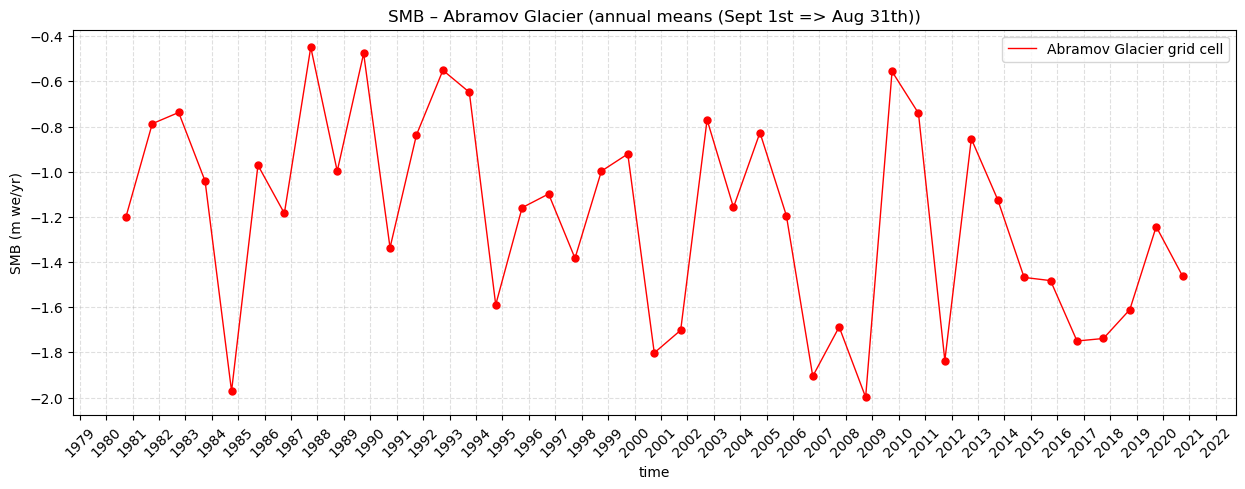

In [106]:
#SMB Annual (from Sept 1 to Aug 31)

plt.figure(figsize=(15,5))

# Point précis Jasgulem
ds_SMB_abra = ds_SMB.isel(Y=iY, X=iX)
ds_SMB_abra_annual = ds_SMB_abra.resample(time="A-SEP").sum().sel(time=slice("1980-09-01", "2021-08-31"))/1000

ds_SMB_abra_annual.plot(label="Abramov Glacier grid cell", linewidth=1, color="red")

plt.plot(ds_SMB_abra_annual.time,
         ds_SMB_abra_annual,
         'o', color='red', markersize=5)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Abramov Glacier (annual means (Sept 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-SEP' is deprecated and will be removed in a future version, please use 'YS-SEP' instead.
  self.index_grouper = pd.Grouper(


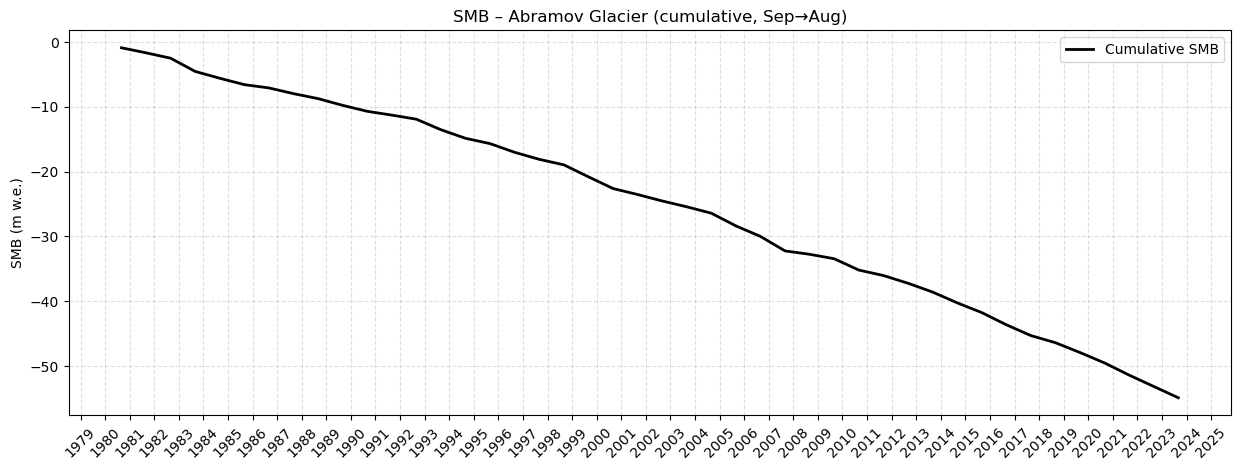

In [108]:
# =========================
# SMB annuel (Sep → Aug)
# =========================

ds_SMB_abra = ds_SMB.isel(Y=iY, X=iX)

ds_SMB_abra_annual = (
    ds_SMB_abra
    .resample(time="AS-SEP")
    .sum()
    .sel(time=slice("1980-09-01", "2024-08-31"))
    / 1000  # m w.e.
)

# =========================
# CUMUL SMB
# =========================

ds_SMB_cum = ds_SMB_abra_annual.cumsum(dim="time")

# =========================
# PLOT
# =========================

plt.figure(figsize=(15,5))

plt.plot(
    ds_SMB_cum.time,
    ds_SMB_cum,
    '-',
    color='black',
    linewidth=2,
    label="Cumulative SMB"
)

# =========================
# AXES
# =========================

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.title("SMB – Abramov Glacier (cumulative, Sep→Aug)")
plt.ylabel("SMB (m w.e.)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()